<a href="https://colab.research.google.com/github/giulia-belgiovine/Memorability/blob/main/memorability.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Mount Google Drive**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Import useful libraries

In [ ]:
# #install resmem if needed
# !pip install resmem
# from resmem import ResMem, transformer

In [ ]:
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
import pandas as pd
from PIL import Image
from csv import reader
from os.path import expanduser
import os, sys, copy, glob, tqdm, argparse
import time
import csv
import pickle


In [ ]:
# Torch
import torch
from torch import nn
from torch.optim import Adam, lr_scheduler
from torch.nn import CrossEntropyLoss
from torchvision import datasets, models, transforms
from torch.autograd import Variable
from torch.utils.data import Dataset, DataLoader, ConcatDataset
from torch.utils.data.dataset import random_split
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torchvision.transforms import ToTensor, RandomResizedCrop, RandomHorizontalFlip,  RandomRotation, Compose, Normalize, RandomCrop, Resize, CenterCrop

# torch.use_deterministic_algorithms(True)


# Read MemCatDataset

Category-based set of 10K images quantified on memorability. The set consists of five broader memorability-relevant semantic categories (animal, sports, food, landscapes, vehicles), with 2K exemplars each, further divided into different subcategories (e.g., bear, pigeon, cat, etc. for animal).



In [ ]:
csv_path = "/content/drive/MyDrive/BMM_2023/projects/Datasets/MemCat_data"
imgs_path = "/content/drive/MyDrive/BMM_2023/projects/Datasets/MemCat"

class_dict = {"animal": 0, "food":1, "landscape":2, "sports":3, "vehicle":4}
np.random.seed(0)

memcat_frame = pd.read_csv(os.path.join(csv_path,"memcat_image_data.csv"))
memcat_frame[:3]

,Unnamed: 0,image_file,category,subcategory,current_height,current_width,source,searched_label,resize_factor,H,FA,n_resp,memorability_wo_fa_correction,memorability_w_fa_correction
0,1,000000003481.jpg,animal,bear,316.0,500.0,coco,bear,1.0,55,4,98,0.561224,0.520408
1,2,000000005745.jpg,animal,bear,427.0,640.0,coco,bear,1.0,64,4,81,0.790123,0.740741
2,3,000000011552.jpg,animal,bear,427.0,640.0,coco,bear,1.0,75,5,104,0.721154,0.673077


## Dataset exploration

In [ ]:
#this is just to do sanity check on datset images

img_idx = 700
score = memcat_frame['memorability_w_fa_correction'].loc[img_idx]
img_cat = memcat_frame['category'].loc[img_idx]
img_subcat = memcat_frame['subcategory'].loc[img_idx]
img_name = memcat_frame['image_file'].loc[img_idx]

img = Image.open(os.path.join(imgs_path,img_cat,img_subcat,img_name)).convert('RGB')
y = torch.Tensor([float(score)])
#image_x = self.transform(img) #just if you want to use it as input of the model

plt.figure()
plt.axis("off")
plt.imshow(np.asarray(img))
print(img.size)

print("Class: {}. Memorability Score: {}".format(img_cat, y))


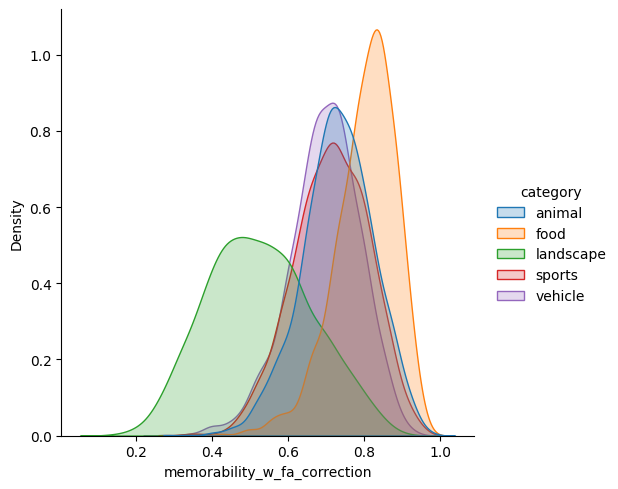

In [ ]:
#Plot distribution per each category in subplots
sns.displot(memcat_frame, x="memorability_w_fa_correction", hue="category", kind="kde", fill=True)

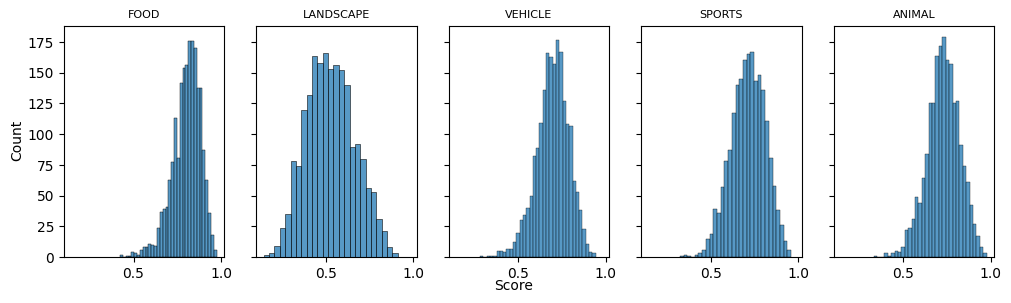

In [ ]:
#Plot distribution per each category in one figure
class_names = set(memcat_frame['category'])
n_classes = len(class_names)

fig, axs = plt.subplots(1,5,sharex=True, sharey=True,figsize=(12,3))

for clss_name, ax in zip(class_names, axs.ravel()):
  sub_df = memcat_frame.loc[memcat_frame['category'] == clss_name]
  sns.histplot(sub_df, x="memorability_w_fa_correction", ax=ax)

  # chart formatting
  ax.set_title(clss_name.upper(), fontsize=8)
  ax.set_xlabel("")
  ax.set_ylabel("")

fig.text(0.5, 0.0004, 'Score', ha='center')
fig.text(0.08, 0.5, 'Count', va='center', rotation='vertical')

plt.show()

In [ ]:
#plot 5 best and 5 worst samples per category
class_to_check = 'animal'

subframe = memcat_frame.loc[(memcat_frame['category'] == class_to_check)]
sorted_dataframe = subframe.sort_values(by=['memorability_w_fa_correction'])

best_five = sorted_dataframe[-5:]
worst_five = sorted_dataframe[:5]

fig, axs = plt.subplots(5,1,sharex=True, sharey=True,figsize=(12,15))

for i, ax in zip(np.arange(5), axs.ravel()):

  im_name = best_five['image_file'].values[i]
  im_subcat = best_five['subcategory'].values[i]
  im = Image.open(os.path.join(imgs_path,class_to_check,im_subcat,im_name)).convert('RGB')
  ax.imshow(np.asarray(im))

  # chart formatting
  ax.set_title(best_five['memorability_w_fa_correction'].values[0], fontsize=8)
  ax.set_xlabel("")
  ax.set_ylabel("")
  ax.axis("off")

plt.show()

# Classification Experiment

### Set Dataset for Training/Test

In [ ]:
np.random.seed(0)

In [ ]:
n_samples_val = 200            #Take 200 samples per ach class in the test set
samples_per_class = 800        #Once done the median split on the remaining train_set, take 800 samples for each score class ('high'/'low')
final_list_test = []
final_list_train = []
np.random.seed(0)

for k, v in class_dict.items():

    subframe = memcat_frame.loc[memcat_frame["category"]==k]

    #Take 200 random samples from test
    df_val = subframe.sample(n=n_samples_val)
    df_train = subframe.drop(df_val.index)
    # print("Lenght of test dataframe: {}. Lenght of the train dataframe: {}".format(len(df_val), len(df_train)))

    # Perform a median split based on mem. score on the remaining train set.
    # Top 50th percentile put in group '2'. Bottom 50th percentile be put in group '1'
    score = df_train["memorability_w_fa_correction"]
    df_train["median_split"] = (score < score.quantile()).replace({True:1, False:2})

    low_score_df = df_train.loc[df_train["median_split"] == 1]
    high_score_df = df_train.loc[df_train["median_split"] == 2]
    # print("Lenght of first median split: {}. Lenght of second median split: {}.".format(len(low_score_df), len(high_score_df)))

    # Take 800 from low_score and 800 from hig score to remove the ones too close to median
    composed_dataset = pd.concat([high_score_df[:samples_per_class], low_score_df[-samples_per_class:]])
    composed_dataset = composed_dataset.sort_values(by='memorability_w_fa_correction', ascending=True)

    final_list_train.append(composed_dataset)
    final_list_test.append(df_val)

train_df = pd.concat(final_list_train) #len of 1600*5=8000
test_df = pd.concat(final_list_test)   #len of 200*5=1000
print("Total lenght of: Train Dataset --> {}. Test Dataset --> {}".format(len(train_df), len(test_df)))

Total lenght of: Train Dataset --> 8000. Test Dataset --> 1000


In [ ]:
#check number of samples per categories
for k, v in class_dict.items():

  n_val = len(test_df.loc[test_df['category'] == k])
  n_train = len(train_df.loc[train_df['category'] == k])

  print('Number of samples for category {}: Train --> {}. Test --> {}'.format(k, n_train, n_val))

Number of samples for category animal: Train --> 1600. Test --> 200
Number of samples for category food: Train --> 1600. Test --> 200
Number of samples for category landscape: Train --> 1600. Test --> 200
Number of samples for category sports: Train --> 1600. Test --> 200
Number of samples for category vehicle: Train --> 1600. Test --> 200


In [ ]:
#Just making a more compact train and test Dataframe
def save_compact_df(dataframe):
  dictlist = []
  for i, row in dataframe.iterrows():

      imgstr = row["image_file"]
      #index = i
      img_path = os.path.join(imgs_path, row['category'], row['subcategory'], row['image_file'])
      subcategory = row['subcategory']
      label = row['category']
      score = row["memorability_w_fa_correction"]

      # add these to a dictionary:
      row = {'image_name': imgstr, 'label': label, 'subcategory':subcategory, 'score': score, 'img_path': img_path}  #'image_index': index,

      # append dictionary to running list of rows
      dictlist.append(row)

  df_compact = pd.DataFrame(dictlist)
  return df_compact

train_compact = save_compact_df(train_df)  #the dataset is sorted per category
test_compact = save_compact_df(test_df)

### Define experiment

In [ ]:
## CREATE DATASET FOR DIFFERENT EXPERIMENTS
np.random.seed(0)
df_exp1_list = []
df_exp2_list = []
df_exp3_list = []

for k in class_dict.keys():

  df = train_compact.loc[train_compact['label'] == k]

  #Experiment 1
  df_rnd = df.sample(n=samples_per_class)  #created by random sampling of 800 imgs per classes
  df_exp1_list.append(df_rnd)

  #Experiment 2
  df_high = df[-samples_per_class:]       #created by sampling highest score 800 imgs per classes
  df_exp2_list.append(df_high)

  #Experiment 3
  df_low = df[:samples_per_class]         #created by sampling lowest score 800 imgs per classes
  df_exp3_list.append(df_low)

  print("Low-score range for class {} --> [{} : {}]".format(k, df_low['score'].min(), df_low['score'].max()))
  print("High-score range fpr class {} --> [{} : {}]".format(k, df_high['score'].min(), df_high['score'].max()))


## DATASET PER EXPERIMENTS
train_exp_rnd = pd.concat(df_exp1_list).sample(frac = 1)
train_exp_high = pd.concat(df_exp2_list).sample(frac = 1)
train_exp_low = pd.concat(df_exp3_list).sample(frac = 1)

Low-score range for class animal --> [0.333333333333333 : 0.732558139534884]
High-score range fpr class animal --> [0.732673267326733 : 0.97752808988764]
Low-score range for class food --> [0.423076923076923 : 0.813559322033898]
High-score range fpr class food --> [0.813725490196078 : 0.975]
Low-score range for class landscape --> [0.144067796610169 : 0.521739130434783]
High-score range fpr class landscape --> [0.522222222222222 : 0.910714285714286]
Low-score range for class sports --> [0.323529411764706 : 0.715686274509804]
High-score range fpr class sports --> [0.715789473684211 : 0.959183673469388]
Low-score range for class vehicle --> [0.280898876404494 : 0.700934579439252]
High-score range fpr class vehicle --> [0.701030927835051 : 0.941860465116279]


In [ ]:
# SELECT THE TRAINING DATASET FOR THE EXPERIMENT
train_exp = {'name': 'Random', 'df': train_exp_rnd.reset_index()}
# train_exp = {'name': 'High_Score', 'df': train_exp_high.reset_index()}
# train_exp = {'name': 'Low_Score', 'df': train_exp_low.reset_index()}

# SELECT THE TEST DATASET FOR THE EXPERIMENT
test_exp = test_compact.sample(frac = 1).reset_index()

In [ ]:
low_test_list = []
high_test_list = []

for k, v in class_dict.items():

    subframe = test_exp.loc[test_exp["label"]==k]
    print("Category {}".format(k))

    # Perform a median split based on mem. score on the remaining train set.
    # Top 50th percentile put in group '2'. Bottom 50th percentile be put in group '1'
    score = subframe["score"]
    test_exp["median_split"] = (score < score.quantile()).replace({True:1, False:2})

    low_score_test = test_exp.loc[test_exp["median_split"] == 1]
    high_score_test = test_exp.loc[test_exp["median_split"] == 2]
    # print("Lenght of first median split: {}. Lenght of second median split: {}.".format(len(low_score_df), len(high_score_df)))

    low_test_list.append(low_score_test)
    high_test_list.append(high_score_test)

    print("Max: {}, Min: {}, Len {}".format(low_score_test['score'].min(), low_score_test['score'].max(), len(low_score_test)))
    print("Max: {}, Min: {}, Len {}".format(high_score_test['score'].min(), high_score_test['score'].max(), len(high_score_test)))


low_test_df = pd.concat(low_test_list) #len of 1600*5=8000
high_test_df = pd.concat(high_test_list)

Category animal
Max: 0.451612903225806, Min: 0.723809523809524, Len 100
Max: 0.724137931034483, Min: 0.948453608247423, Len 100
Category food
Max: 0.471153846153846, Min: 0.814432989690722, Len 100
Max: 0.814814814814815, Min: 0.936842105263158, Len 100
Category landscape
Max: 0.212962962962963, Min: 0.509259259259259, Len 100
Max: 0.515463917525773, Min: 0.833333333333333, Len 100
Category sports
Max: 0.465346534653465, Min: 0.720430107526882, Len 100
Max: 0.721649484536082, Min: 0.925, Len 100
Category vehicle
Max: 0.39622641509434, Min: 0.697916666666667, Len 100
Max: 0.700934579439252, Min: 0.896551724137931, Len 100


In [ ]:
## TEST EXPERIMENT
test_exp = low_test_df

In [ ]:
test_exp

In [ ]:
sns.displot(test_exp, x="score", hue="label", kind="kde", fill=True)

In [ ]:
sns.displot(low_test_df, x="score", hue="label", kind="kde", fill=True)
sns.displot(high_test_df, x="score", hue="label", kind="kde", fill=True)

In [ ]:
# our CustomDataset inherits its class structure from torch's Dataset
class CustomDataset(Dataset):
    def __init__(self, train_df, test_df, partition, image_transforms=None, imgs_path=""):
        # here we define whether the images sampled come are for training or eval:
        if partition == 'train':
            image_df = train_df['df'].reset_index()
        if partition == 'val':
            image_df = test_df.reset_index()

        print("Woking with training set: {}".format(train_df['name']))

        # we then save our image paths to a vector
        self.images = image_df['image_name']
        self.images_path = image_df['img_path']

        # this variable saves the names of our labels
        self.classes = image_df['label'].unique()

        # here, we transform our labels into integers
        self.labels = pd.Categorical(image_df['label']).codes

        # finally, we define our image transforms
        self.transforms = image_transforms

    def __getitem__(self, index):
        # in the arguments below, index refers to a row of our dataframe
        # to actually load an image we use PIL, converting the image to RGB
        img = Image.open(self.images_path[index]).convert('RGB')
        label = self.labels[index]

        # if we have transforms, we apply them here:
        if self.transforms:
            img = self.transforms(img)


        # finally, we return our img and label as a tuple
        return img, label

    # a convenience function to get the number of items in the dataset
    def __len__(self):
        return self.images.shape[0]

### Train the Model

In [ ]:
torch.manual_seed(0)

data_transforms = {
    'train': transforms.Compose([
        # transforms.RandomCrop(224),
        transforms.Resize((224,224)),
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(15),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'val': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}

dataloaders = {x: DataLoader(CustomDataset(train_exp, test_exp, x, data_transforms['train'], imgs_path),
                             batch_size=128, shuffle=True, num_workers=1, drop_last=True)
                             for x in ['train', 'val']}

dataset_sizes = {x: len(dataloaders[x].dataset) for x in ['train', 'val']}
class_names = dataloaders['train'].dataset.classes

Woking with training set: Random
Woking with training set: Random


In [ ]:
import pickle
def train_model(model, criterion, optimizer, scheduler, filename, num_epochs, dataloaders):

    # with open(filename + '_new.pkl', 'wb') as file:

    since = time.time()
    best_model_wts = copy.deepcopy(model.state_dict()) #initialize a variable to hold the best model weights across epoch
    best_acc = 0.0 # initialize a variable to track the best accuracy across epochs

    model.cuda() #place model on gpu, if available

    iterator = tqdm.tqdm(range(num_epochs))

    epoch_acc_list = []
    epoch_loss_list = []
    epoch_best_acc_list = []

    for epoch in iterator:
        print('\n Epoch {}/{}'.format(epoch, num_epochs - 1))
        print('-' * 10)

        # Each epoch has a training and validation phase
        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()  # Set model to training mode
            else:
                model.eval()   # Set model to evaluate mode

            # initialize variables to track stats
            running_loss = 0.0
            running_corrects = 0

            # Iterate over data.
            for inputs, labels in tqdm.tqdm(dataloaders[phase]):
                inputs = inputs.cuda()
                labels = labels.cuda()

                # zero out any previously calculated gradients
                optimizer.zero_grad()

                # make a forward pass through the network
                # use the loss to update weights only if training
                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels.long())

                    # backward pass + update parameters only if in training phase
                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                # statistics
                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

            if phase == 'train':
                #update learning rate
                scheduler.step()

            if phase == 'val':
                # Compute average validation loss
                avg_val_loss = sum(epoch_loss_list[-len(dataloaders['val']):]) / len(dataloaders['val'])
                # Update the scheduler with the average validation loss for early stopping
                scheduler.step(avg_val_loss)

                # Check if early stopping condition is met
                if scheduler.state_dict()['_last_lr'][0] < 1e-5:
                    print("Early stopping triggered.")
                    break

            # update our records of loss and accuracy
            epoch_loss = running_loss / dataset_sizes[phase]
            epoch_acc = running_corrects.double() / dataset_sizes[phase]

            print("\nEpoch Loss {} is: {}".format(phase, epoch_loss))
            print("Epoch Acc. {} is: {}".format(phase, epoch_acc))

            epoch_loss_list.append(epoch_loss)
            epoch_acc_list.append(epoch_acc.cpu().detach().numpy())

            # deep copy the model if it's the best one so far:
            if phase == 'val' and epoch_acc > best_acc:
                best_acc = epoch_acc
                best_model_wts = copy.deepcopy(model.state_dict())
                torch.save(model.state_dict(), '{}_best.pth'.format(filename))

    epoch_best_acc_list.append(best_acc.cpu().detach().numpy())

    print('\nBest Validation Accuracy: {:4f}'.format(best_acc))
    time_elapsed = time.time() - since
    print('\nTraining complete in {:.0f}m {:.0f}s'.format(
        time_elapsed // 60, time_elapsed % 60))
    print('-' * 10)

    #load best model weights from those stored across the epochs
    model.load_state_dict(best_model_wts)
    model.to('cpu') # return model to cpu

    results = {'epochs_best_accuracy': epoch_best_acc_list, 'epochs_loss': epoch_loss_list, 'epochs_accuracy':epoch_acc_list}
    # pickle.dump(results, file)
    # print(f"Data saved to {filename}")

    return model, results

In [ ]:
import torchvision.models as models
results_path = "/content/drive/MyDrive/BMM_2023/projects/memorability_results/classification2"
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
field_names= ['epochs_best_accuracy', 'epochs_loss', 'epochs_accuracy']

file_title = "ExpRand_googlenet_pretrained_10_testLow"
file_name = os.path.join(results_path, file_title)
print("Check file_name once again: {}".format(file_name))

def instantiate_parameters():

    # load our pretrained model from torchvision
    # model = models.resnet50(pretrained=False)
    # model = models.squeezenet1_0(pretrained=True)
    # model = models.mobilenet_v2(pretrained=True)
    # model = torch.hub.load('pytorch/vision:v0.10.0', 'shufflenet_v2_x1_0', pretrained=True)
    model = torch.hub.load('pytorch/vision:v0.10.0', 'googlenet', pretrained=True)
    # model = models.resnet18(pretrained=True)

    num_epochs = 10

    # our loss function:
    criterion = CrossEntropyLoss()

    # select optimizer for backpropagating errors
    optimizer = Adam(model.parameters(), lr=0.0005, weight_decay=1e-4)
    scheduler = ReduceLROnPlateau(optimizer, mode='min', patience=10, factor=0.1, verbose=True)

    # Specify one cycle policy learning rate scheduler
    one_cycle_scheduler = lr_scheduler.OneCycleLR(optimizer, max_lr=1e-01, steps_per_epoch=len(dataloaders['train']), epochs=3)

    return model, num_epochs, file_name, criterion, optimizer, scheduler, one_cycle_scheduler

Check file_name once again: /content/drive/MyDrive/BMM_2023/projects/memorability_results/classification2/ExpRand_googlenet_pretrained_10_testLow


In [ ]:
all_results = []

with open(file_name + '_new.pkl', 'wb') as file:
    for i in range(1):
        torch.manual_seed(i)
        print("Iteration Seed: {}".format(i))

        dataloaders = {x: DataLoader(CustomDataset(train_exp, test_exp, x, data_transforms['train'], imgs_path),
                                    batch_size=128, shuffle=True, num_workers=1, drop_last=True) for x in ['train', 'val']}

        dataset_sizes = {x: len(dataloaders[x].dataset) for x in ['train', 'val']}

        model, num_epochs, file_name, criterion, optimizer, scheduler, one_cycle_scheduler = instantiate_parameters()

        model, results = train_model(model, criterion, optimizer, one_cycle_scheduler, file_name,
                                    num_epochs=num_epochs, dataloaders=dataloaders)

        all_results.append(results)

        torch.cuda.empty_cache()

    #Save results as csv file (in addition to pickle)
    df_results = pd.DataFrame(all_results)

    pickle.dump(df_results, file)
    print(f"Data saved to {file_name}")

    df_results.to_csv(file_name)

Iteration Seed: 0
Woking with training set: Random
Woking with training set: Random


Using cache found in /root/.cache/torch/hub/pytorch_vision_v0.10.0
/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=GoogLeNet_Weights.IMAGENET1K_V1`. You can also use `weights=GoogLeNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
  0%|          | 0/10 [00:00<?, ?it/s]


 Epoch 0/9
----------



100%|██████████| 31/31 [00:34<00:00,  1.13s/it]



Epoch Loss train is: 1.1908669815063477
Epoch Acc. train is: 0.6795


...


Epoch Loss val is: 0.39444277954101564
Epoch Acc. val is: 0.626

 Epoch 9/9
----------



100%|██████████| 31/31 [00:35<00:00,  1.13s/it]



Epoch Loss train is: 0.24599889087677002
Epoch Acc. train is: 0.9087500000000001



100%|██████████| 10/10 [06:31<00:00, 39.18s/it]



Epoch Loss val is: 0.4955859832763672
Epoch Acc. val is: 0.618

Best Validation Accuracy: 0.626000

Training complete in 6m 32s
----------
Data saved to /content/drive/MyDrive/BMM_2023/projects/memorability_results/classification2/ExpRand_googlenet_pretrained_10_testLow


## Plot results

In [ ]:
%cd /content/drive/MyDrive/BMM_2023/projects/memorability_results/classification2

/content/drive/MyDrive/BMM_2023/projects/memorability_results/classification2


In [ ]:
!ls

In [ ]:
import pickle
file_pkl = 'ExpRand_googlenet_pretrained_10_testLow_new.pkl'

In [ ]:
#load pickle file
with open(file_pkl, 'rb') as file:
    loaded_data = pickle.load(file)

# Convert loaded data to a DataFrame
df_pickle = pd.DataFrame(loaded_data)

In [ ]:
df_pickle

,epochs_best_accuracy,epochs_loss,epochs_accuracy
0,[0.63],"[1.678697145462036, 8.30010546875, 0.579854751...","[0.5885, 0.216, 0.78025, 0.41600000000000004, ..."


In [ ]:
#create new dataframe for plots
accuracy_list = df_pickle['epochs_accuracy'].values[0]
train_accuracy = [e for (i,e) in enumerate(accuracy_list) if (i%2) == 0]
test_accuracy = [e for (i,e) in enumerate(accuracy_list) if (i%2) != 0]

loss_list = df_pickle['epochs_loss'].values[0]
train_loss = [e for (i,e) in enumerate(loss_list) if (i%2) == 0]
test_loss = [e for (i,e) in enumerate(loss_list) if (i%2) != 0]

best_val_acc = df_pickle['epochs_best_accuracy'].values[0]

data = {
    'iteration': 0*len(test_loss),
    'epoch_best_accuracy': best_val_acc*len(test_loss),
    'train_accuracies': train_accuracy,
    'test_accuracies': test_accuracy,
    'train_losses': train_loss,
    'test_losses': test_loss
}

df_plot = pd.DataFrame(data)

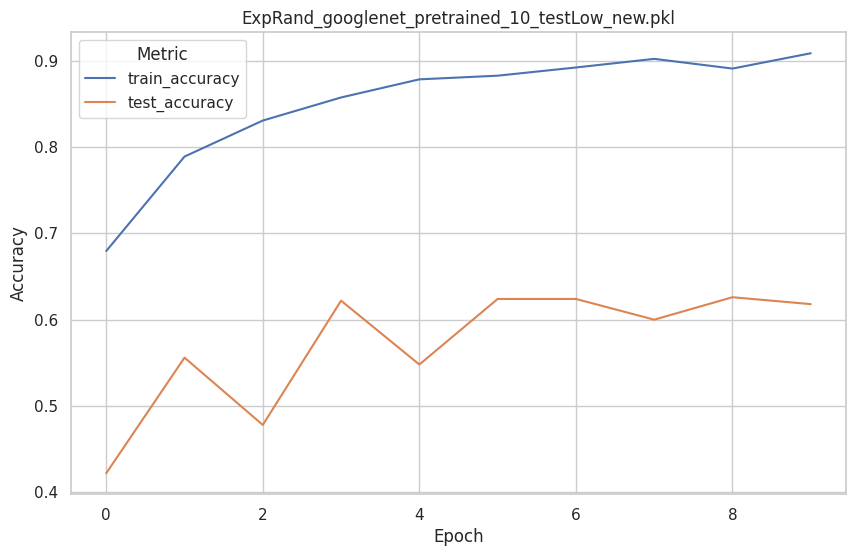

In [ ]:
#Read data from csv
# df = pd.read_csv(filecsv)

data = {
    'train_accuracy': df_plot['train_accuracies'].apply(pd.to_numeric).values,  # List of 50 values
    'test_accuracy': df_plot['test_accuracies'].apply(pd.to_numeric).values   # List of 50 values
}

# Create the DataFrame for Seaborn
df_sns = pd.DataFrame(data)

# Reshape the DataFrame for plotting
df_melted = pd.melt(df_sns.reset_index().rename(columns={'index': 'epoch'}), id_vars=['epoch'], value_vars=['train_accuracy', 'test_accuracy'])


# Create the lineplot using Seaborn
plt.figure(figsize=(10, 6))
sns.set(style="whitegrid")
sns.lineplot(data=df_melted, x='epoch', y='value', hue='variable')
plt.title(file_pkl)
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(title='Metric')
plt.show()


## Load/Plot more models

In [ ]:
pickle_directory = "/content/drive/MyDrive/BMM_2023/projects/memorability_results/classification2"
dataframes = []
for filename in os.listdir(pickle_directory):
    if filename.endswith('10_new.pkl') and filename.startswith('ExpHigh'):
        print(filename)
        filepath = os.path.join(pickle_directory, filename)
        loaded_data = pd.read_pickle(filepath)
        # loaded_data = pickle.load(filepath)
        df = pd.DataFrame([loaded_data])
        dataframes.append(df)

# Concatenate the list of DataFrames into a single DataFrame
combined_df_high = pd.concat(dataframes, ignore_index=True)
combined_df_high = combined_df_high.rename_axis('Models')

# Now you can work with the combined DataFrame
combined_df_high

ExpHigh_Resnet18_pretrained_10_new.pkl
ExpHigh_mobilenet_pretrained_10_new.pkl
ExpHigh_shufflenetv2_pretrained_10_new.pkl
ExpHigh_googlenet_pretrained_10_new.pkl


,epochs_best_accuracy,epochs_loss,epochs_accuracy
Models,,,
0,[0.582],"[2.4751400146484377, 668.4739375, 1.0241417160...","[0.41600000000000004, 0.163, 0.5615, 0.276, 0...."
1,[0.761],"[1.9865608501434326, 5.316182800292969, 0.7185...","[0.5055000000000001, 0.225, 0.73075, 0.686, 0...."
2,[0.8230000000000001],"[1.1247773456573487, 1.3997670440673828, 0.448...","[0.77925, 0.641, 0.85575, 0.767, 0.90325, 0.78..."
3,[0.76],"[1.2457865314483643, 4.452527954101562, 0.5609...","[0.65425, 0.381, 0.7857500000000001, 0.618, 0...."


In [ ]:
pickle_directory = "/content/drive/MyDrive/BMM_2023/projects/memorability_results/classification2"
dataframes = []
for filename in os.listdir(pickle_directory):
    if filename.endswith('10_new.pkl') and filename.startswith('ExpLow'):
        print(filename)
        filepath = os.path.join(pickle_directory, filename)
        loaded_data = pd.read_pickle(filepath)
        # loaded_data = pickle.load(filepath)
        df = pd.DataFrame([loaded_data])
        dataframes.append(df)

# Concatenate the list of DataFrames into a single DataFrame
combined_df_low = pd.concat(dataframes, ignore_index=True)
combined_df_low = combined_df_low.rename_axis('Models')

# Now you can work with the combined DataFrame
combined_df_low

ExpLow_Resnet18_pretrained_10_new.pkl
ExpLow_mobilenetv2_pretrained_10_new.pkl
ExpLow_shufflenetv2_pretrained_10_new.pkl
ExpLow_googlenet_pretrained_10_new.pkl


,epochs_best_accuracy,epochs_loss,epochs_accuracy
Models,,,
0,[0.47500000000000003],"[2.4792671737670897, 98.48552734375, 0.9332183...","[0.41300000000000003, 0.23800000000000002, 0.6..."
1,[0.755],"[1.6927103614807129, 6.724138427734375, 0.5940...","[0.6235, 0.277, 0.7765, 0.602, 0.8295, 0.669, ..."
2,[0.803],"[0.9914315252304077, 7.27692529296875, 0.35352...","[0.80775, 0.447, 0.88025, 0.757, 0.9175, 0.794..."
3,[0.726],"[1.0603918266296386, 6.883351013183594, 0.4917...","[0.728, 0.379, 0.82125, 0.674, 0.8535, 0.624, ..."


In [ ]:
dataframes = []
#create new dataframe for plots
for ind, row in combined_df.iterrows():
    accuracy_list = row['epochs_accuracy']
    train_accuracy = [e for (i,e) in enumerate(accuracy_list) if (i%2) == 0]
    test_accuracy = [e for (i,e) in enumerate(accuracy_list) if (i%2) != 0]

    loss_list = row['epochs_loss']
    train_loss = [e for (i,e) in enumerate(loss_list) if (i%2) == 0]
    test_loss = [e for (i,e) in enumerate(loss_list) if (i%2) != 0]

    best_val_acc = row['epochs_best_accuracy']

    data = {
        'model': [ind]*len(test_loss),
        'epoch': np.arange(len(test_loss)),
        'epoch_best_accuracy': best_val_acc*len(test_loss),
        'train_accuracies': train_accuracy,
        'test_accuracies': test_accuracy,
        'train_losses': train_loss,
        'test_losses': test_loss
    }

    df_plot = pd.DataFrame(data)
    dataframes.append(df_plot)

combined_df_plot = pd.concat(dataframes, ignore_index=True)

In [ ]:
# Calculate the average and standard deviation across models for each epoch
df = combined_df_plot
average_df = df.groupby('epoch')[['train_accuracies', 'test_accuracies']].mean()
std_df = df.groupby('epoch')[['train_accuracies', 'test_accuracies']].std()

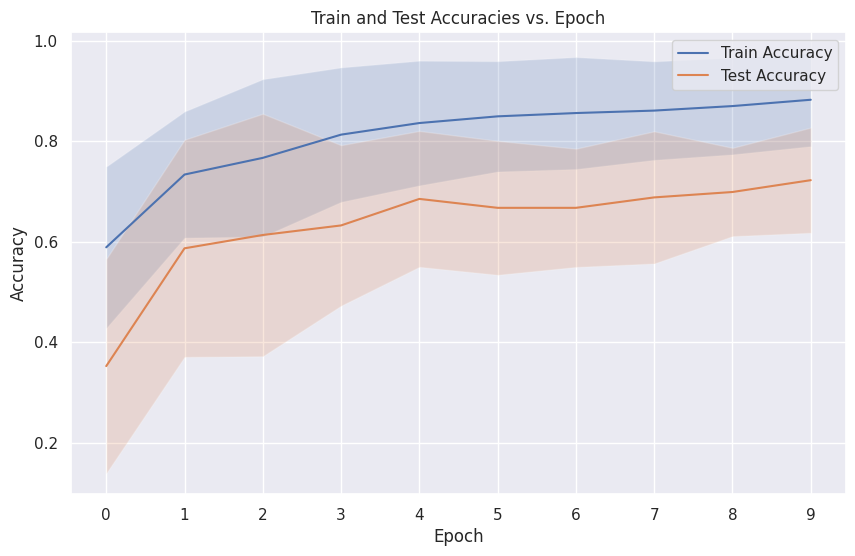

In [ ]:
# Create a lineplot using seaborn
plt.figure(figsize=(10, 6))
sns.set(style="darkgrid")

combined_df_plot['model'] = combined_df_plot['model'].astype(str)
combined_df_plot['epoch'] = combined_df_plot['epoch'].astype(str)

# Plot train accuracies with error bars
sns.lineplot(data=average_df, x=average_df.index, y='train_accuracies', label='Train Accuracy')
plt.fill_between(average_df.index, average_df['train_accuracies'] - std_df['train_accuracies'],
                 average_df['train_accuracies'] + std_df['train_accuracies'], alpha=0.2)

# Plot test accuracies with error bars
sns.lineplot(data=average_df, x=average_df.index, y='test_accuracies', label='Test Accuracy')
plt.fill_between(average_df.index, average_df['test_accuracies'] - std_df['test_accuracies'],
                 average_df['test_accuracies'] + std_df['test_accuracies'], alpha=0.2)

plt.title('Train and Test Accuracies vs. Epoch')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.show()

# Continual Leaning Experiment

In [ ]:
# Use Avalanche Library
!pip install avalanche-lib

In [ ]:
# Avalanche
from torch.optim import SGD
from avalanche.benchmarks import nc_benchmark
from avalanche.benchmarks.utils import make_classification_dataset
from avalanche.benchmarks.classic import SplitCIFAR10, PermutedMNIST
from avalanche.benchmarks.generators import filelist_benchmark, dataset_benchmark, \
                                            tensors_benchmark, paths_benchmark

from avalanche.models import pytorchcv_wrapper, SimpleMLP, resnet32, SimpleCNN
from avalanche.training.determinism.rng_manager import RNGManager

from avalanche.training.supervised import Naive
from avalanche.training.plugins import ReplayPlugin, EvaluationPlugin

from avalanche.evaluation.metrics import (
    forgetting_metrics,
    accuracy_metrics,
    loss_metrics,
)
from avalanche.logging import InteractiveLogger

In [ ]:
# Remember to load checkpoints by setting the same random seed used when creating them...
RNGManager.set_random_seeds(1234)
imgs_path = "/content/drive/MyDrive/BMM_2023/projects/Datasets/MemCat"
class_dict = {"animal": 0, "food":1, "landscape":2, "sports":3, "vehicle":4}

## Organize Dataset for CL

In [ ]:
def split_dataset_in_task(dataframe_train, dataframe_test, class_category):

  train_class = dataframe_train.loc[dataframe_train['label']==class_category]
  test_class = dataframe_test.loc[dataframe_test['label']==class_category]

  return train_class, test_class

exp = {'Random': {'Dataframe': train_exp_rnd},
       'High':   {'Dataframe': train_exp_high},
       'Low':    {'Dataframe': train_exp_low}}


#a single train class is 800. A single test class is 200
train_class1, test_class1 = split_dataset_in_task(exp.get('Random')['Dataframe'], test_exp, 'animal')
train_class2, test_class2 = split_dataset_in_task(exp.get('Random')['Dataframe'], test_exp, 'food')
train_class3, test_class3 = split_dataset_in_task(exp.get('Random')['Dataframe'], test_exp, 'landscape')
train_class4, test_class4 = split_dataset_in_task(exp.get('Random')['Dataframe'], test_exp, 'sports')
train_class5, test_class5 = split_dataset_in_task(exp.get('Random')['Dataframe'], test_exp, 'vehicle')


In [ ]:
# Prepare training and test set for each task
train_task0 = torch.utils.data.DataLoader(train_class1 + train_class2 + train_class3)
train_task1 = torch.utils.data.DataLoader(train_class4 + train_class5)

test_task0 = torch.utils.data.DataLoader(test_class1 + test_class2 + test_class3)
test_task1 = torch.utils.data.DataLoader(test_class4 + test_class5)

In [ ]:
# --- CREATE CUSTOM DATASET
# The final dataset "train_experiences" is a list of 5 list (one for each class).
# Each list contains 2000 tuples (name of the file --> str, label --> int)

#first, we create a list of paths + class labels
# train_experiences = []
# for k, v in class_dict.items():

#     subframe = memcat_frame.loc[memcat_frame["category"]==k]
#     experience_paths = []

#     for i, row in subframe.iterrows():
#       name = row["image_file"]
#       img_subcat = row['subcategory']
#       instance_tuple = (os.path.join(imgs_path,k,img_subcat,name), v)
#       experience_paths.append(instance_tuple)

#     train_experiences.append(experience_paths)

In [ ]:
#Function to separate each category subset in random training and test split
# def create_train_test_dataset_class(class_id):
#   dataset = train_experiences[class_id]
#   test_lenght = int(len(dataset)*0.3)
#   train_lenght = int(len(dataset)*0.7)
#   train_class, test_class = torch.utils.data.random_split(dataset, [train_lenght, test_lenght])

#   train_class = torch.utils.data.DataLoader(train_class)
#   test_class = torch.utils.data.DataLoader(test_class)

#   return train_class.dataset, test_class.dataset

# #a single train class is 1400. A single test class is 600
# train_class1, test_class1 = create_train_test_dataset_class(0) #animal
# train_class2, test_class2 = create_train_test_dataset_class(1) #food
# train_class3, test_class3 = create_train_test_dataset_class(2) #landscape
# train_class4, test_class4 = create_train_test_dataset_class(3) #sports
# train_class5, test_class5 = create_train_test_dataset_class(4) #vehicle

# # Prepare training and test set for each task
# train_task0 = torch.utils.data.DataLoader(train_class1 + train_class2 + train_class3) #1400*2 training examples of classe [0,1]
# train_task1 = torch.utils.data.DataLoader(train_class4 + train_class5) #1400*3 training examples of classe [2,3,4]

# test_task0 = torch.utils.data.DataLoader(test_class1 + test_class2 + test_class3) #600*2 test samples of classes [0,1]
# test_task1 = torch.utils.data.DataLoader(test_class4 + test_class5) #600*3 test samples of classes [2,3,4]

# Create Avalanche Scenario (Task IL)

In [ ]:
# Data transformation
train_transform = Compose([
    Resize((224,224)),
    RandomHorizontalFlip(),
    RandomRotation(15),
    ToTensor(),
    Normalize((0.1307,), (0.3081,))  #[0.485, 0.456, 0.406], [0.229, 0.224, 0.225]
])

test_transform = Compose([
    Resize((224,224)),
    ToTensor(),
    Normalize((0.1307,), (0.3081,))  #[0.485, 0.456, 0.406], [0.229, 0.224, 0.225]
])

In [ ]:
#Here we create a GenericCLScenario object
scenario = paths_benchmark(
    [train_task0.dataset, train_task1.dataset],
    [test_task0.dataset, test_task1.dataset],
    task_labels=[0, 1],
    # complete_test_set_only=True,
    train_transform=train_transform,
    eval_transform=test_transform,
    )


train_stream = scenario.train_stream
test_stream = scenario.test_stream

#check if the scenario we designed is correct
for experience in train_stream:

    print("Start of task ", experience.task_label)
    print('Classes in this task:', experience.classes_in_this_experience)

    exp_id = experience.current_experience
    training_dataset = experience.dataset

    # The current Pytorch training set can be easily recovered through the experience
    current_training_set = experience.dataset
    #print("example of first training sample", experience.dataset[0])
    print('This task contains', len(current_training_set), 'training examples')

    # we can recover the corresponding test experience in the test stream
    current_test_set = test_stream[exp_id].dataset
    print('This task contains', len(current_test_set), 'test examples')

## Naive approach

In [ ]:
# --- CONFIG

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

# Model getter: specify dataset and depth of the network.
model = torch.hub.load('pytorch/vision:v0.10.0', 'squeezenet1_0', pretrained=False)
optimizer = Adam(model.parameters(), lr=0.0005)
criterion = CrossEntropyLoss()

# choose some metrics and evaluation method
interactive_logger = InteractiveLogger()

eval_plugin = EvaluationPlugin(
    accuracy_metrics(minibatch=True, epoch=True, experience=True, stream=True),
    loss_metrics(minibatch=True, epoch=True, experience=True, stream=True),
    forgetting_metrics(experience=True),
    loggers=[interactive_logger],
)

#create strategy
strategy = Naive(model=model,
                optimizer=optimizer,
                criterion=criterion,
                train_mb_size=64,
                eval_mb_size=64,
                train_epochs=5,
                device=device,

                # plugins=[ReplayPlugin(mem_size=1000)],  #Naive, with Replay
                evaluator=eval_plugin)


print("Starting experiment...")
results = []


#train on the selected benchmark with the chosen strategy
#each "experience" here is a task
for experience in train_stream:
    print("Start training on experience ", experience.current_experience)
    strategy.train(experience, num_workers=10)
    print("Training completed")
    strategy.eval(test_stream, num_workers=10)


print("Computing accuracy on the whole test set")
results.append(strategy.eval(test_stream))